In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score

In [2]:
df = pd.read_csv('Food_Delivery_Times.csv')

df.drop(columns=['Order_ID', 'Time_of_Day', 'Vehicle_Type'], inplace=True)

for col in ['Weather', 'Traffic_Level', 'Courier_Experience_yrs']:
    df[col] = df[col].fillna(df[col].mode()[0])

df = pd.get_dummies(df, columns=['Weather', 'Traffic_Level'], drop_first=True, dtype=int)

Dataset shape: (1000, 10)

Features used: ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs', 'Weather_Foggy', 'Weather_Rainy', 'Weather_Snowy', 'Weather_Windy', 'Traffic_Level_Low', 'Traffic_Level_Medium']

Target — Delivery_Time_min:
count    1000.00
mean       56.73
std        22.07
min         8.00
25%        41.00
50%        55.50
75%        71.00
max       153.00
Name: Delivery_Time_min, dtype: float64


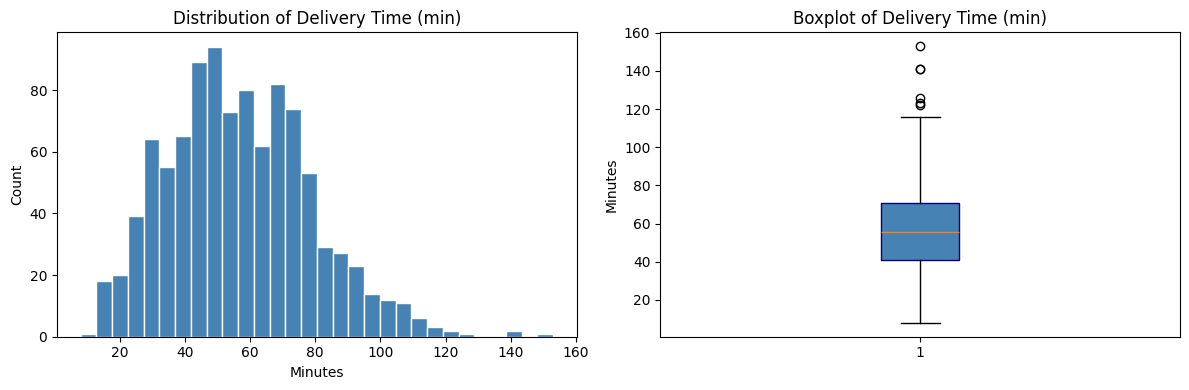

In [3]:
X = df.drop(columns=['Delivery_Time_min'])
y = df['Delivery_Time_min']

print("Dataset shape:", df.shape)
print("\nFeatures used:", X.columns.tolist())
print("\nTarget — Delivery_Time_min:")
print(y.describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(y, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Delivery Time (min)')
axes[0].set_xlabel('Minutes')
axes[0].set_ylabel('Count')

axes[1].boxplot(y, vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='navy'))
axes[1].set_title('Boxplot of Delivery Time (min)')
axes[1].set_ylabel('Minutes')

plt.tight_layout()
plt.show()

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"\nTrain size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")


Train size: 800  |  Test size: 200


In [6]:
# this is the helper function used for eval of models
def evaluate_regression(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    mae  = mean_absolute_error(y_te, preds)
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    r2   = r2_score(y_te, preds)
    cv   = cross_val_score(model, X_tr, y_tr, cv=5,
                           scoring='r2').mean()
    print(f"[{name}]  MAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:.4f}  CV-R²={cv:.4f}")
    return {'Model': name, 'MAE': round(mae,3),
            'RMSE': round(rmse,3), 'R²': round(r2,4), 'CV R²': round(cv,4)}

In [7]:
# baseline models
print("BASELINE MODELS (before hyperparameter tuning)")
print()

baseline_results = []

lr  = LinearRegression()
baseline_results.append(evaluate_regression(
    'Linear Regression', lr, X_train_scaled, y_train, X_test_scaled, y_test))

ridge = Ridge(alpha=1.0)
baseline_results.append(evaluate_regression(
    'Ridge Regression', ridge, X_train_scaled, y_train, X_test_scaled, y_test))

rf_base = RandomForestRegressor(n_estimators=100, random_state=42)
baseline_results.append(evaluate_regression(
    'Random Forest (baseline)', rf_base,
    X_train_scaled, y_train, X_test_scaled, y_test))

gb_base = GradientBoostingRegressor(n_estimators=100, random_state=42)
baseline_results.append(evaluate_regression(
    'Gradient Boosting (baseline)', gb_base,
    X_train_scaled, y_train, X_test_scaled, y_test))

baseline_df = pd.DataFrame(baseline_results)
print("\nBaseline Summary:")
print(baseline_df.to_string(index=False))

BASELINE MODELS (before hyperparameter tuning)

[Linear Regression]  MAE=5.923  RMSE=8.795  R²=0.8274  CV-R²=0.7535
[Ridge Regression]  MAE=5.929  RMSE=8.797  R²=0.8273  CV-R²=0.7535
[Random Forest (baseline)]  MAE=7.288  RMSE=10.549  R²=0.7518  CV-R²=0.6826
[Gradient Boosting (baseline)]  MAE=6.602  RMSE=9.524  R²=0.7976  CV-R²=0.7016

Baseline Summary:
                       Model   MAE   RMSE     R²  CV R²
           Linear Regression 5.923  8.795 0.8274 0.7535
            Ridge Regression 5.929  8.797 0.8273 0.7535
    Random Forest (baseline) 7.288 10.549 0.7518 0.6826
Gradient Boosting (baseline) 6.602  9.524 0.7976 0.7016


In [8]:
print("HYPERPARAMETER TUNING — Random Forest (GridSearchCV, cv=5)")
print()

rf_param_grid = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=rf_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
rf_grid.fit(X_train_scaled, y_train)

print("\nBest parameters (RF):", rf_grid.best_params_)
print(f"Best CV R² (RF): {rf_grid.best_score_:.4f}")

HYPERPARAMETER TUNING — Random Forest (GridSearchCV, cv=5)

Fitting 5 folds for each of 81 candidates, totalling 405 fits

Best parameters (RF): {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
Best CV R² (RF): 0.7058


In [9]:
print("HYPERPARAMETER TUNING — Gradient Boosting (RandomizedSearchCV, cv=5)")

from scipy.stats import randint, uniform

gb_param_dist = {
    'n_estimators':  randint(100, 400),
    'max_depth':     randint(2, 8),
    'learning_rate': uniform(0.01, 0.2),
    'min_samples_split': randint(2, 15),
    'min_samples_leaf':  randint(1, 8),
    'subsample':     uniform(0.6, 0.4), 
}

gb_rand = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_distributions=gb_param_dist,
    n_iter=30,          
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
gb_rand.fit(X_train_scaled, y_train)

print("\nBest parameters (GB):", gb_rand.best_params_)
print(f"Best CV R² (GB): {gb_rand.best_score_:.4f}")

HYPERPARAMETER TUNING — Gradient Boosting (RandomizedSearchCV, cv=5)
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best parameters (GB): {'learning_rate': np.float64(0.09989013482764068), 'max_depth': 2, 'min_samples_leaf': 7, 'min_samples_split': 8, 'n_estimators': 161, 'subsample': np.float64(0.7300733288106989)}
Best CV R² (GB): 0.7280


PERFORMANCE COMPARISON: Before vs After Tuning
[Random Forest (tuned)]  MAE=7.026  RMSE=10.245  R²=0.7658  CV-R²=0.7058
[Gradient Boosting (tuned)]  MAE=6.253  RMSE=9.277  R²=0.8080  CV-R²=0.7280

Comparison Table:
                       Model   MAE   RMSE     R²  CV R²
    Random Forest (baseline) 7.288 10.549 0.7518 0.6826
Gradient Boosting (baseline) 6.602  9.524 0.7976 0.7016
       Random Forest (tuned) 7.026 10.245 0.7658 0.7058
   Gradient Boosting (tuned) 6.253  9.277 0.8080 0.7280


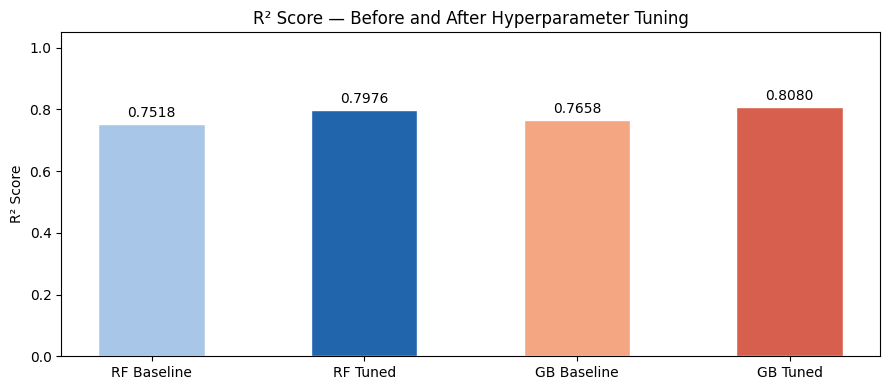

In [10]:
# compare before/after tuning 
print("PERFORMANCE COMPARISON: Before vs After Tuning")

tuned_results = []

rf_best = rf_grid.best_estimator_
tuned_results.append(evaluate_regression(
    'Random Forest (tuned)', rf_best,
    X_train_scaled, y_train, X_test_scaled, y_test))

gb_best = gb_rand.best_estimator_
tuned_results.append(evaluate_regression(
    'Gradient Boosting (tuned)', gb_best,
    X_train_scaled, y_train, X_test_scaled, y_test))

# side-by-side comparison table
compare_models = ['Random Forest (baseline)', 'Random Forest (tuned)',
                  'Gradient Boosting (baseline)', 'Gradient Boosting (tuned)']
compare_df = pd.concat([baseline_df, pd.DataFrame(tuned_results)])
compare_df = compare_df[compare_df['Model'].isin(compare_models)].reset_index(drop=True)

print("\nComparison Table:")
print(compare_df.to_string(index=False))

# bar chart: R² before vs after
fig, ax = plt.subplots(figsize=(9, 4))
labels  = ['RF Baseline', 'RF Tuned', 'GB Baseline', 'GB Tuned']
r2_vals = compare_df['R²'].tolist()
colors  = ['#a8c7e8', '#2166ac', '#f4a582', '#d6604d']
bars = ax.bar(labels, r2_vals, color=colors, edgecolor='white', width=0.5)
ax.bar_label(bars, fmt='%.4f', padding=3)
ax.set_ylim(0, 1.05)
ax.set_ylabel('R² Score')
ax.set_title('R² Score — Before and After Hyperparameter Tuning')
plt.tight_layout()
plt.show()

In [11]:
# Final Model Selection

print("ALL MODELS — Summary Table")

all_results = []

# Re-fit each model cleanly
models_to_compare = {
    'Linear Regression':         LinearRegression(),
    'Ridge Regression':          Ridge(alpha=1.0),
    'Random Forest (baseline)':  RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting (base)':  GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Random Forest (tuned)':     rf_grid.best_estimator_,
    'Gradient Boosting (tuned)': gb_rand.best_estimator_,
}

for name, model in models_to_compare.items():
    all_results.append(
        evaluate_regression(name, model,
                            X_train_scaled, y_train,
                            X_test_scaled, y_test))

summary_df = pd.DataFrame(all_results).sort_values('R²', ascending=False)
print("\n")
print(summary_df.to_string(index=False))

ALL MODELS — Summary Table
[Linear Regression]  MAE=5.923  RMSE=8.795  R²=0.8274  CV-R²=0.7535
[Ridge Regression]  MAE=5.929  RMSE=8.797  R²=0.8273  CV-R²=0.7535
[Random Forest (baseline)]  MAE=7.288  RMSE=10.549  R²=0.7518  CV-R²=0.6826
[Gradient Boosting (base)]  MAE=6.602  RMSE=9.524  R²=0.7976  CV-R²=0.7016
[Random Forest (tuned)]  MAE=7.026  RMSE=10.245  R²=0.7658  CV-R²=0.7058
[Gradient Boosting (tuned)]  MAE=6.253  RMSE=9.277  R²=0.8080  CV-R²=0.7280


                    Model   MAE   RMSE     R²  CV R²
        Linear Regression 5.923  8.795 0.8274 0.7535
         Ridge Regression 5.929  8.797 0.8273 0.7535
Gradient Boosting (tuned) 6.253  9.277 0.8080 0.7280
 Gradient Boosting (base) 6.602  9.524 0.7976 0.7016
    Random Forest (tuned) 7.026 10.245 0.7658 0.7058
 Random Forest (baseline) 7.288 10.549 0.7518 0.6826


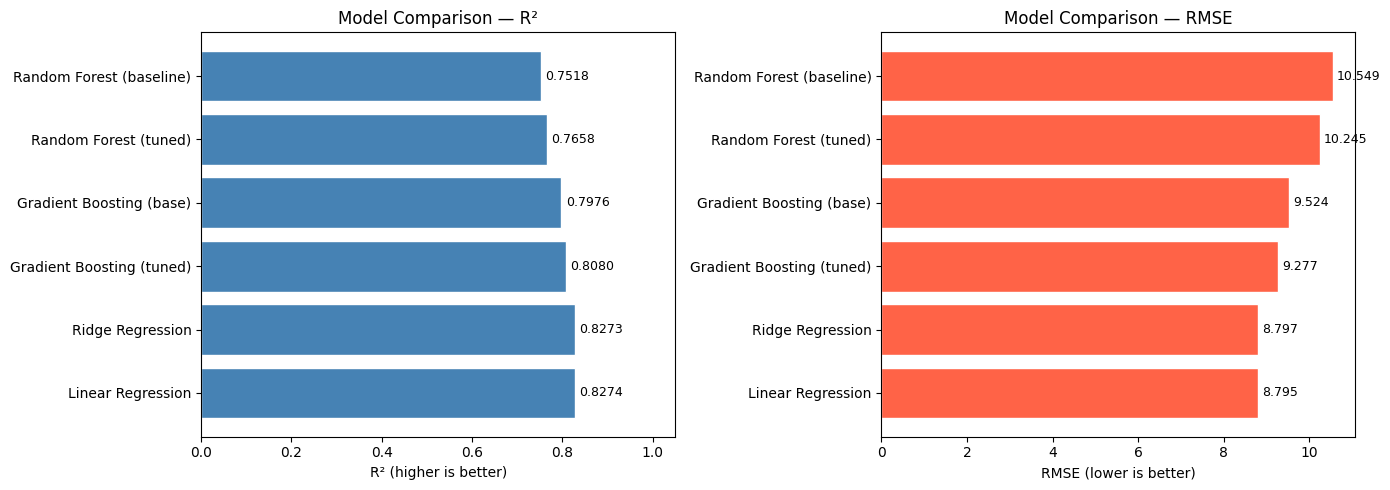

In [12]:
# visual summary

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_names = summary_df['Model'].tolist()
x_pos = range(len(model_names))

# R²
axes[0].barh(model_names, summary_df['R²'], color='steelblue', edgecolor='white')
axes[0].set_xlabel('R² (higher is better)')
axes[0].set_title('Model Comparison — R²')
axes[0].set_xlim(0, 1.05)
for i, v in enumerate(summary_df['R²']):
    axes[0].text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=9)

# RMSE
axes[1].barh(model_names, summary_df['RMSE'], color='tomato', edgecolor='white')
axes[1].set_xlabel('RMSE (lower is better)')
axes[1].set_title('Model Comparison — RMSE')
for i, v in enumerate(summary_df['RMSE']):
    axes[1].text(v + 0.1, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [13]:
FINAL_MODEL_NAME = 'Linear Regression'
final_model = gb_rand.best_estimator_

print(f"SELECTED FINAL MODEL: {FINAL_MODEL_NAME}")

SELECTED FINAL MODEL: Linear Regression


In [14]:
final_preds = final_model.predict(X_test_scaled)
residuals   = y_test.values - final_preds

print(f"Residual stats:")
print(f"  Mean residual : {residuals.mean():.3f} min (bias)")
print(f"  Std of residuals: {residuals.std():.3f} min")
print(f"  Min residual  : {residuals.min():.3f} min")
print(f"  Max residual  : {residuals.max():.3f} min")

Residual stats:
  Mean residual : -0.831 min (bias)
  Std of residuals: 9.240 min
  Min residual  : -21.186 min
  Max residual  : 55.559 min


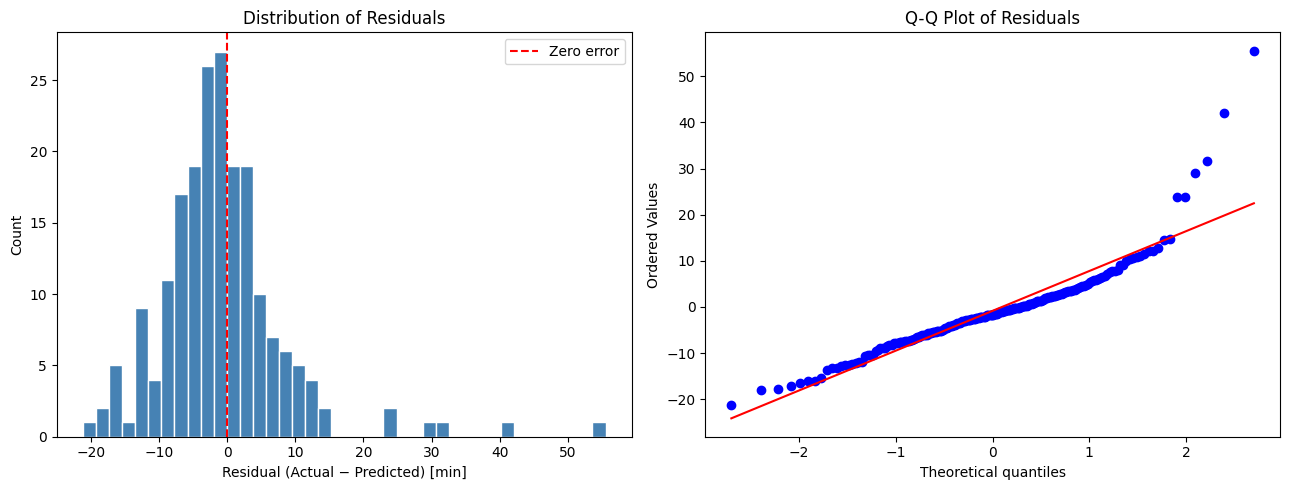

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(residuals, bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero error')
axes[0].set_title('Distribution of Residuals')
axes[0].set_xlabel('Residual (Actual − Predicted) [min]')
axes[0].set_ylabel('Count')
axes[0].legend()

# Q-Q plot to check if residuals are approximately normal
import scipy.stats as stats
stats.probplot(residuals, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.show()

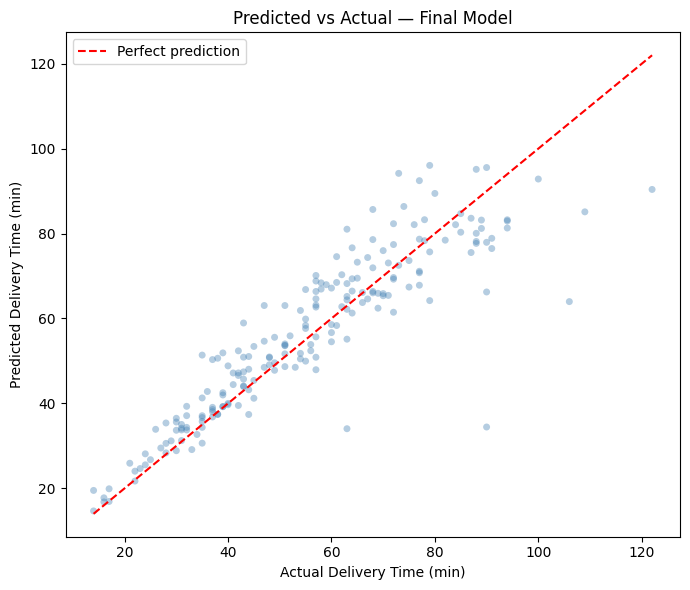

In [16]:
# predicted vs actual
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, final_preds, alpha=0.4, color='steelblue', edgecolor='none', s=25)
min_val = min(y_test.min(), final_preds.min())
max_val = max(y_test.max(), final_preds.max())
ax.plot([min_val, max_val], [min_val, max_val],
        'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Delivery Time (min)')
ax.set_ylabel('Predicted Delivery Time (min)')
ax.set_title('Predicted vs Actual — Final Model')
ax.legend()
plt.tight_layout()
plt.show()

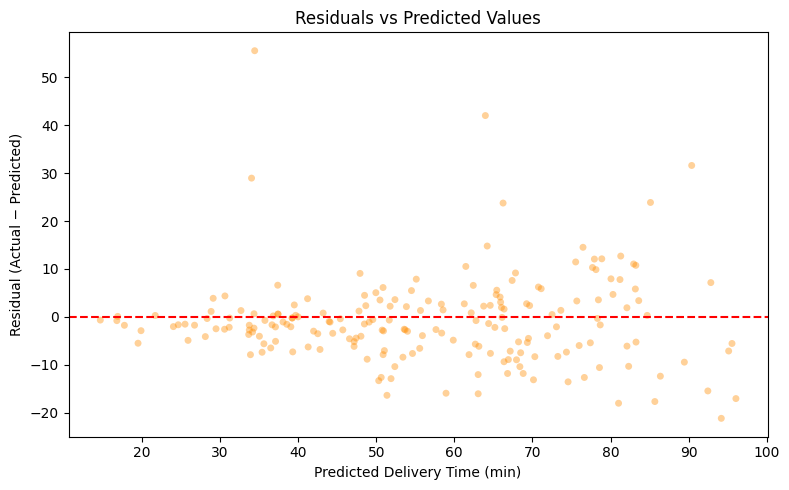

In [17]:
# heteroscedasticity check
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(final_preds, residuals, alpha=0.4, color='darkorange', edgecolor='none', s=25)
ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('Predicted Delivery Time (min)')
ax.set_ylabel('Residual (Actual − Predicted)')
ax.set_title('Residuals vs Predicted Values')
plt.tight_layout()
plt.show()

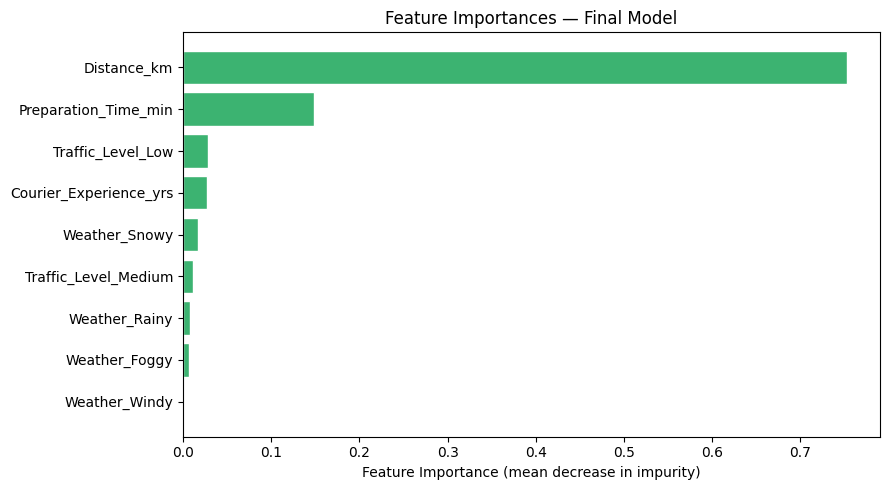

               Feature  Importance
           Distance_km    0.752775
  Preparation_Time_min    0.148774
     Traffic_Level_Low    0.028560
Courier_Experience_yrs    0.027129
         Weather_Snowy    0.016612
  Traffic_Level_Medium    0.010785
         Weather_Rainy    0.007856
         Weather_Foggy    0.007112
         Weather_Windy    0.000398


In [18]:
# feature importance 
importances = final_model.feature_importances_
feat_names  = X.columns.tolist()
imp_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
imp_df = imp_df.sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(imp_df['Feature'], imp_df['Importance'],
        color='mediumseagreen', edgecolor='white')
ax.set_xlabel('Feature Importance (mean decrease in impurity)')
ax.set_title('Feature Importances — Final Model')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(imp_df.to_string(index=False))

In [19]:
# individual mistake examples 
error_df = X_test.copy().reset_index(drop=True)
error_df['Actual']    = y_test.values
error_df['Predicted'] = final_preds.round(2)
error_df['Residual']  = residuals.round(2)
error_df['Abs_Error'] = np.abs(residuals).round(2)

# sort by absolute error to surface the worst predictions
worst_errors = error_df.sort_values('Abs_Error', ascending=False).head(15)


print("TOP 15 WORST PREDICTIONS (largest absolute error)")
print()
print(worst_errors[['Actual', 'Predicted', 'Residual', 'Abs_Error']].to_string())

TOP 15 WORST PREDICTIONS (largest absolute error)

     Actual  Predicted  Residual  Abs_Error
8        90      34.44     55.56      55.56
50      106      63.98     42.02      42.02
46      122      90.40     31.60      31.60
84       63      34.04     28.96      28.96
160     109      85.12     23.88      23.88
123      90      66.25     23.75      23.75
67       73      94.19    -21.19      21.19
169      63      81.03    -18.03      18.03
114      68      85.68    -17.68      17.68
14       79      96.06    -17.06      17.06
135      35      51.38    -16.38      16.38
82       47      63.06    -16.06      16.06
51       43      58.94    -15.94      15.94
72       77      92.46    -15.46      15.46
152      79      64.21     14.79      14.79


In [20]:
# over-prediction vs under-prediction
over_pred  = error_df[error_df['Residual'] < 0]   # model said MORE than actual
under_pred = error_df[error_df['Residual'] > 0]   # model said LESS than actual

print(f"\nOver-predictions  (model overestimates time): {len(over_pred)}  samples")
print(f"Under-predictions (model underestimates time): {len(under_pred)} samples")
print(f"\nMean abs error — over-predicted  : {over_pred['Abs_Error'].mean():.3f} min")
print(f"Mean abs error — under-predicted : {under_pred['Abs_Error'].mean():.3f} min")

print("\nActual delivery time stats for WORST 15 errors:")
print(worst_errors['Actual'].describe().round(2))

print("\nActual delivery time stats for ALL test samples:")
print(error_df['Actual'].describe().round(2))


Over-predictions  (model overestimates time): 122  samples
Under-predictions (model underestimates time): 77 samples

Mean abs error — over-predicted  : 5.807 min
Mean abs error — under-predicted : 7.041 min

Actual delivery time stats for WORST 15 errors:
count     15.00
mean      76.27
std       24.69
min       35.00
25%       63.00
50%       77.00
75%       90.00
max      122.00
Name: Actual, dtype: float64

Actual delivery time stats for ALL test samples:
count    200.00
mean      55.44
std       21.22
min       14.00
25%       39.00
50%       55.00
75%       70.00
max      122.00
Name: Actual, dtype: float64


In [21]:
mae_final  = mean_absolute_error(y_test, final_preds)
rmse_final = np.sqrt(mean_squared_error(y_test, final_preds))
r2_final   = r2_score(y_test, final_preds)


print(f"FINAL MODEL: {FINAL_MODEL_NAME}")
print()
print(f"  MAE  (Mean Absolute Error):       {mae_final:.4f} minutes")
print(f"  RMSE (Root Mean Squared Error):   {rmse_final:.4f} minutes")
print(f"  R²   (Coefficient of Determination): {r2_final:.4f}")
print()
print(f"Interpretation:")
print(f"  On average, the model's delivery time prediction is off by")
print(f"  {mae_final:.2f} minutes from the true delivery time.")
print(f"  The model explains {r2_final*100:.1f}% of the variance in delivery time.")

# final metrics in a table
final_metrics = pd.DataFrame([{
    'Metric': 'MAE',  'Value': round(mae_final, 4),  'Unit': 'minutes'},
    {'Metric': 'RMSE', 'Value': round(rmse_final, 4), 'Unit': 'minutes'},
    {'Metric': 'R²',   'Value': round(r2_final, 4),   'Unit': '(dimensionless)'}
])
print("\nFinal Metrics Table:")
print(final_metrics.to_string(index=False))

FINAL MODEL: Linear Regression

  MAE  (Mean Absolute Error):       6.2527 minutes
  RMSE (Root Mean Squared Error):   9.2771 minutes
  R²   (Coefficient of Determination): 0.8080

Interpretation:
  On average, the model's delivery time prediction is off by
  6.25 minutes from the true delivery time.
  The model explains 80.8% of the variance in delivery time.

Final Metrics Table:
Metric  Value            Unit
   MAE 6.2527         minutes
  RMSE 9.2771         minutes
    R² 0.8080 (dimensionless)
